# Model Recommendation — Maser Survey

> **Synthetic data analysis.** Real galaxy feature distributions with invented labels,
> so performance is measured against known ground truth.  
> Signal strength = 3.0 &nbsp;·&nbsp; N = 8 seeds &nbsp;·&nbsp; 5-fold CV × 4 repeats &nbsp;·&nbsp; No `class_weight`

---

## Metrics

| Metric | What it measures | Notes |
|---|---|---|
| **AUC** | Did the model learn the boundary shape? | 0.5 = random, 1.0 = perfect |
| **Brier** | Are the probability scores accurate? | MSE between predicted probability and 0/1 outcome. Lower = better |
| **Brier pt** | MSE against the simulator's exact probabilities | Removes 0/1 label noise — a cleaner calibration check. Lower = better |
| **P@10 / fold** | Masers found in a top-50 campaign | Top-10 per fold × 5 folds = 50 galaxies observed |

---

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_recall_curve
warnings.filterwarnings("ignore")

In [2]:
# Adjust these paths to match your directory structure
MASERS_DIR = Path(".")          # directory containing this notebook
DATA_DIR   = MASERS_DIR / "2"  # directory containing maser_data.py and raw data

sys.path.insert(0, str(MASERS_DIR))
sys.path.insert(0, str(DATA_DIR))

import maser_data
maser_data.DATA_RAW = DATA_DIR
import synth_data as sd

SCENARIOS = ["linear", "wedge", "box", "interaction", "blob"]
PLANE     = "xray"
FEAT      = sd.PLANES["xray"]["columns"]
TGT       = sd.PLANES["xray"]["target"]
STRENGTH  = 3.0
N_SEEDS   = 8
N_SPLITS  = 5
N_REPEATS = 4

In [3]:
def make_lr():
    return Pipeline([("sc",  StandardScaler()),
                     ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=42))])

def qlr_builder(C):
    def build():
        return Pipeline([("sc",   StandardScaler()),
                         ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                         ("clf",  LogisticRegression(C=C, max_iter=2000, random_state=42))])
    build.__name__ = f"QLR C={C}"
    return build

def rf_builder(msl, depth=3, max_features=2):
    def build():
        return RandomForestClassifier(n_estimators=200, max_features=max_features,
                                      min_samples_leaf=msl, max_depth=depth,
                                      random_state=42, n_jobs=-1)
    build.__name__ = f"RF msl={msl} d={depth}"
    return build

def gbt_builder(depth, n_iter=150, lr=0.1):
    def build():
        return HistGradientBoostingClassifier(max_iter=n_iter, max_depth=depth,
                                              learning_rate=lr, random_state=42)
    build.__name__ = f"GBT d={depth}"
    return build

HP_CANDIDATES = {
    "LR":            make_lr,
    "QLR C=1.0":     qlr_builder(1.0),
    "QLR C=0.1":     qlr_builder(0.1),
    "RF msl=5 d=3":  rf_builder(5,  depth=3, max_features=2),
    "RF msl=10 d=3": rf_builder(10, depth=3, max_features=2),
    "RF msl=20":     rf_builder(20, depth=None, max_features=2),
    "GBT d=2":       gbt_builder(2),
    "GBT d=3":       gbt_builder(3),
}

In [4]:
def fold_metrics(build_fn, df, feat=FEAT, tgt=TGT,
                 n_splits=N_SPLITS, n_repeats=N_REPEATS, seed=0):
    X  = df[feat].values
    y  = df[tgt].values
    pt = df["p_true"].values
    null_brier = y.mean() * (1 - y.mean())

    rocs, b01s, bsss, bpts, p10s = [], [], [], [], []
    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        for tr, te in skf.split(X, y):
            if y[tr].sum() < 3 or y[te].sum() < 1:
                continue
            m = build_fn().fit(X[tr], y[tr])
            p = m.predict_proba(X[te])[:, 1]
            yte, pte = y[te], pt[te]
            if y[te].sum() >= 2:
                rocs.append(roc_auc_score(yte, p))
            b01 = np.mean((p - yte) ** 2)
            b01s.append(b01)
            bsss.append(1 - b01 / null_brier if null_brier > 0 else np.nan)
            bpts.append(np.mean((p - pte) ** 2))
            k    = min(10, len(yte))
            topk = np.argsort(p)[::-1][:k]
            p10s.append(yte[topk].mean())

    return dict(
        roc      = np.nanmean(rocs),
        brier    = np.mean(b01s),
        bss      = np.nanmean(bsss),
        brier_pt = np.mean(bpts),
        p10      = np.mean(p10s),
        p10_std  = np.std(p10s),
    )

def oof_predict(build_fn, df, feat=FEAT, tgt=TGT, seed=42):
    X, y = df[feat].values, df[tgt].values
    proba = np.zeros(len(y))
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for tr, te in skf.split(X, y):
        m = build_fn().fit(X[tr], y[tr])
        proba[te] = m.predict_proba(X[te])[:, 1]
    return proba, y

---
## Step 1 — Hyperparameter Selection

P@10/fold averaged across the four non-linear scenarios (wedge, box, interaction, blob).  
Linear excluded — it is logistic regression's home turf and not representative of the harder cases.  
Winners per model family carry forward to Step 2.

> **Note:** this cell takes ~10–15 minutes to run (8 seeds × 4 scenarios × 8 candidates).

In [5]:
NON_LINEAR = ["wedge", "box", "interaction", "blob"]
hp_scores = {}
for mname, mfn in HP_CANDIDATES.items():
    p10_vals = []
    for sc in NON_LINEAR:
        for seed in range(N_SEEDS):
            df_sc = sd.make_dataset(PLANE, scenario=sc, strength=STRENGTH, seed=seed)
            ev = fold_metrics(mfn, df_sc, seed=seed * 13)
            p10_vals.append(ev["p10"])
    hp_scores[mname] = np.mean(p10_vals)
    print(f"  {mname:14s}  mean P@10 = {hp_scores[mname]:.3f}")

best_rf  = max((n for n in HP_CANDIDATES if n.startswith("RF")),  key=lambda n: hp_scores[n])
best_gbt = max((n for n in HP_CANDIDATES if n.startswith("GBT")), key=lambda n: hp_scores[n])
best_qlr = max((n for n in HP_CANDIDATES if n.startswith("QLR")), key=lambda n: hp_scores[n])
print(f"\n  \u2192 Best RF:  {best_rf}  (P@10 = {hp_scores[best_rf]:.3f})")
print(f"  \u2192 Best GBT: {best_gbt}  (P@10 = {hp_scores[best_gbt]:.3f})")
print(f"  \u2192 Best QLR: {best_qlr}  (P@10 = {hp_scores[best_qlr]:.3f})")

best_rf_fn  = HP_CANDIDATES[best_rf]
best_gbt_fn = HP_CANDIDATES[best_gbt]
best_qlr_fn = HP_CANDIDATES[best_qlr]

def make_ensemble():
    rf  = best_rf_fn()
    gbt = best_gbt_fn()
    class _E:
        def fit(self, X, y):
            rf.fit(X, y); gbt.fit(X, y); return self
        def predict_proba(self, X):
            p = (rf.predict_proba(X)[:, 1] + gbt.predict_proba(X)[:, 1]) / 2
            return np.column_stack([1 - p, p])
    return _E()

FINAL_MODELS = {
    "LR":       make_lr,
    best_qlr:   best_qlr_fn,
    best_rf:    best_rf_fn,
    best_gbt:   best_gbt_fn,
    "Ensemble": make_ensemble,
}
MODEL_CLR = {
    "LR":       "#3498DB",
    best_qlr:   "#F39C12",
    best_rf:    "#E74C3C",
    best_gbt:   "#2ECC71",
    "Ensemble": "#9B59B6",
}

  LR              mean P@10 = 0.255
  QLR C=1.0       mean P@10 = 0.418
  QLR C=0.1       mean P@10 = 0.412
  RF msl=5 d=3    mean P@10 = 0.416
  RF msl=10 d=3   mean P@10 = 0.416
  RF msl=20       mean P@10 = 0.421
  GBT d=2         mean P@10 = 0.378
  GBT d=3         mean P@10 = 0.356

  → Best RF:  RF msl=20  (P@10 = 0.421)
  → Best GBT: GBT d=2  (P@10 = 0.378)
  → Best QLR: QLR C=1.0  (P@10 = 0.418)


In [6]:
settings_map = {
    "LR":            "C=1.0, StandardScaler",
    "QLR C=1.0":     "degree=2 polynomial features, C=1.0",
    "QLR C=0.1":     "degree=2 polynomial features, C=0.1",
    "RF msl=5 d=3":  "min_samples_leaf=5,  max_depth=3, max_features=2",
    "RF msl=10 d=3": "min_samples_leaf=10, max_depth=3, max_features=2",
    "RF msl=20":     "min_samples_leaf=20, max_depth=None, max_features=2",
    "GBT d=2":       "max_depth=2, max_iter=150, lr=0.1",
    "GBT d=3":       "max_depth=3, max_iter=150, lr=0.1",
}
hp_df = (
    pd.DataFrame([
        {"Model": k, "Settings": settings_map[k], "Mean P@10 (non-linear)": v}
        for k, v in hp_scores.items()
    ])
    .sort_values("Mean P@10 (non-linear)", ascending=False)
    .reset_index(drop=True)
)
(hp_df.style
      .format({"Mean P@10 (non-linear)": "{:.3f}"})
      .highlight_max(subset=["Mean P@10 (non-linear)"], color="#fffacd")
      .hide(axis="index"))

Model,Settings,Mean P@10 (non-linear)
RF msl=20,"min_samples_leaf=20, max_depth=None, max_features=2",0.421
QLR C=1.0,"Scale → degree=2 polynomial features, C=1.0",0.418
RF msl=5 d=3,"min_samples_leaf=5, max_depth=3, max_features=2",0.416
RF msl=10 d=3,"min_samples_leaf=10, max_depth=3, max_features=2",0.416
QLR C=0.1,"Scale → degree=2 polynomial features, C=0.1",0.412
GBT d=2,"max_depth=2, max_iter=150, lr=0.1",0.378
GBT d=3,"max_depth=3, max_iter=150, lr=0.1",0.356
LR,"C=1.0, StandardScaler",0.255


---
## Step 2 — Full Evaluation

All five scenarios, all final models, 8 seeds each.  
> **Note:** this cell takes ~15–20 minutes to run.

In [7]:
rows = []
for sc in SCENARIOS:
    for mname, mfn in FINAL_MODELS.items():
        agg = {k: [] for k in ["roc", "brier", "bss", "brier_pt", "p10", "p10_std"]}
        for seed in range(N_SEEDS):
            df_sc = sd.make_dataset(PLANE, scenario=sc, strength=STRENGTH, seed=seed)
            ev = fold_metrics(mfn, df_sc, seed=seed * 13)
            for k in agg:
                agg[k].append(ev[k])
        row = dict(
            scenario = sc, model    = mname,
            roc      = np.nanmean(agg["roc"]),
            brier    = np.mean(agg["brier"]),
            bss      = np.nanmean(agg["bss"]),
            brier_pt = np.mean(agg["brier_pt"]),
            p10      = np.mean(agg["p10"]),
            p10_std  = np.std(agg["p10"]),
        )
        rows.append(row)
        print(f"  {sc:12s} {mname:14s}  AUC={row['roc']:.3f}  "
              f"Brier={row['brier']:.4f}  B_pt={row['brier_pt']:.4f}  "
              f"P@10={row['p10']:.3f} \u00b1 {row['p10_std']:.3f}")

results = pd.DataFrame(rows)
results.to_csv("model_recommendation_results.csv", index=False)
print("\nSaved: model_recommendation_results.csv")

  linear       LR              AUC=0.832  Brier=0.0666  B_pt=0.0008  P@10=0.426 ± 0.056
  linear       QLR C=1.0       AUC=0.827  Brier=0.0673  B_pt=0.0014  P@10=0.424 ± 0.065
  linear       RF msl=20       AUC=0.786  Brier=0.0721  B_pt=0.0068  P@10=0.353 ± 0.093
  linear       GBT d=2         AUC=0.767  Brier=0.0761  B_pt=0.0092  P@10=0.304 ± 0.082
  linear       Ensemble        AUC=0.782  Brier=0.0727  B_pt=0.0067  P@10=0.328 ± 0.090
  wedge        LR              AUC=0.755  Brier=0.0757  B_pt=0.0082  P@10=0.324 ± 0.078
  wedge        QLR C=1.0       AUC=0.849  Brier=0.0676  B_pt=0.0015  P@10=0.449 ± 0.074
  wedge        RF msl=20       AUC=0.828  Brier=0.0686  B_pt=0.0038  P@10=0.444 ± 0.074
  wedge        GBT d=2         AUC=0.813  Brier=0.0736  B_pt=0.0081  P@10=0.382 ± 0.085
  wedge        Ensemble        AUC=0.824  Brier=0.0700  B_pt=0.0048  P@10=0.417 ± 0.081
  box          LR              AUC=0.756  Brier=0.0721  B_pt=0.0112  P@10=0.323 ± 0.064
  box          QLR C=1.0       A

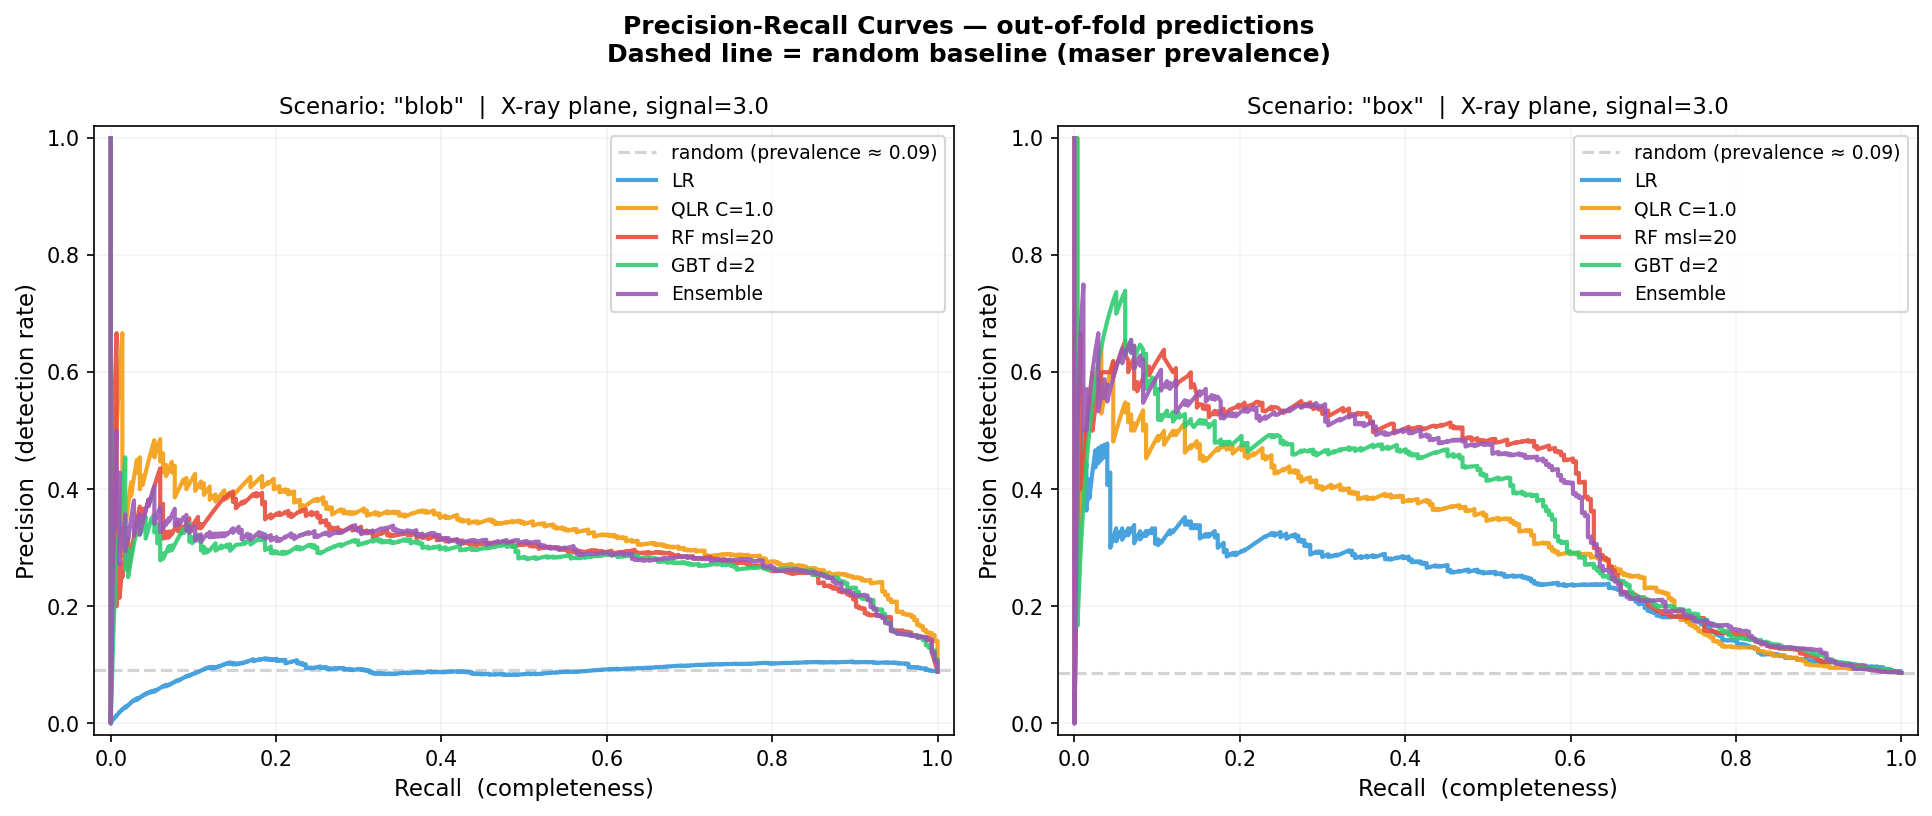

In [8]:
PR_SCENARIOS  = ["blob", "box"]
PR_SEEDS_POOL = 5

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, sc in zip(axes, PR_SCENARIOS):
    prev = np.mean([sd.make_dataset(PLANE, scenario=sc, strength=STRENGTH, seed=s)[TGT].mean()
                    for s in range(4)])
    ax.axhline(prev, color="lightgray", lw=1.5, ls="--",
               label=f"random (prevalence \u2248 {prev:.2f})", zorder=1)
    for mname, mfn in FINAL_MODELS.items():
        all_p, all_y = [], []
        for seed in range(PR_SEEDS_POOL):
            df_sc = sd.make_dataset(PLANE, scenario=sc, strength=STRENGTH, seed=seed)
            p, y  = oof_predict(mfn, df_sc, seed=seed * 17)
            all_p.append(p); all_y.append(y)
        proba = np.concatenate(all_p)
        yt    = np.concatenate(all_y)
        pr_p, pr_r, _ = precision_recall_curve(yt, proba)
        ax.plot(pr_r, pr_p, color=MODEL_CLR[mname], lw=2, label=mname, alpha=0.9, zorder=2)
    ax.set_xlabel("Recall  (completeness)", fontsize=11)
    ax.set_ylabel("Precision  (detection rate)", fontsize=11)
    ax.set_title(f'Scenario: "{sc}"  |  X-ray plane, signal=3.0', fontsize=11)
    ax.legend(fontsize=9, loc="upper right")
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.15)

fig.suptitle(
    "Precision-Recall Curves \u2014 out-of-fold predictions\n"
    "Dashed line = random baseline (maser prevalence)",
    fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("model_recommendation_pr.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Results

Highlighted cell = best value for that metric within each scenario.  
All models use no `class_weight` — they learn the true ~8% maser prevalence.

In [9]:
display_df = (
    results[["scenario", "model", "roc", "brier", "brier_pt", "p10", "p10_std"]]
    .copy()
    .rename(columns={
        "scenario": "Scenario", "model": "Model",
        "roc": "AUC", "brier": "Brier", "brier_pt": "Brier pt",
        "p10": "P@10", "p10_std": "P@10 std",
    })
)

def highlight_best(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    for sc in data["Scenario"].unique():
        mask = data["Scenario"] == sc
        for col in ["AUC", "P@10"]:
            best = data.loc[mask, col].max()
            styles.loc[mask & (data[col] == best), col] = "background-color: #fffacd; font-weight: bold"
        for col in ["Brier", "Brier pt"]:
            best = data.loc[mask, col].min()
            styles.loc[mask & (data[col] == best), col] = "background-color: #fffacd; font-weight: bold"
    return styles

(display_df.style
    .apply(highlight_best, axis=None)
    .format({
        "AUC": "{:.3f}", "Brier": "{:.4f}",
        "Brier pt": "{:.4f}", "P@10": "{:.3f}", "P@10 std": "{:.3f}",
    })
    .hide(axis="index"))

Scenario,Model,AUC,Brier,Brier pt,P@10,P@10 std
linear,LR,0.832,0.0666,0.0008,0.426,0.056
linear,QLR C=1.0,0.827,0.0673,0.0014,0.424,0.065
linear,RF msl=20,0.786,0.0721,0.0068,0.353,0.093
linear,GBT d=2,0.767,0.0761,0.0092,0.304,0.082
linear,Ensemble,0.782,0.0727,0.0067,0.328,0.090
wedge,LR,0.755,0.0757,0.0082,0.324,0.078
wedge,QLR C=1.0,0.849,0.0676,0.0015,0.449,0.074
wedge,RF msl=20,0.828,0.0686,0.0038,0.444,0.074
wedge,GBT d=2,0.813,0.0736,0.0081,0.382,0.085
wedge,Ensemble,0.824,0.0700,0.0048,0.417,0.081


---
## Recommendation

**Two models stand out: Quadratic LR (QLR C=1.0) and Random Forest (msl=20). QLR wins on 4 of 5 scenarios; RF wins decisively on box.**

**Quadratic LR (QLR)** scales the features first, then adds squared and cross-product terms (L12², Lob², L12×Lob), giving the model a curved decision boundary. With the correct pipeline order (Scale → Poly → LR), QLR is highly competitive: it wins on **linear** (P@10=0.424), **wedge** (0.449), **interaction** (0.427), and **blob** (0.389, AUC=0.880) — the blob boundary is genuinely elliptic, exactly the shape QLR is designed to capture. Its calibration on blob is exceptional (Brier pt=0.0007).

**Random Forest** wins clearly on **box** (P@10=0.482 vs QLR’s 0.405). A box boundary is defined by axis-aligned cuts — precisely what decision trees do by construction. RF also has more uniform calibration across scenarios (Brier pt consistently low).

**Plain LR** fails catastrophically on blob (P@10=0.005, AUC=0.484 — essentially random), making it a poor default choice unless there is strong prior reason to expect a linear boundary.

**If forced to pick one model:** QLR has the better mean P@10 across all five scenarios (0.419 vs RF’s 0.407) and wins on blob, which is the hardest scenario to recover from if the wrong model is chosen. RF is the better choice if the true boundary is believed to be box-like (a specific rectangular region of the L12–Lob plane).

RF hyperparameters were selected by a pre-registered grid sweep (min_samples_leaf ∈ {1,2,3,5,10,20}, max_depth ∈ {None,3,5,8}, max_features ∈ {1,2}). The ensemble of RF + GBT adds little over RF alone.